In [1]:
library(tidyverse)
library(cowplot)
library(Seurat)
library(SeuratWrappers)
library(tricycle)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘cowplot’


The following object is masked from ‘package:lubridate’:

    stamp


Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching packa

In [3]:
sc_data <- readRDS("output/FL_CLL_integrated_clean.rds")

In [ ]:
sc_data <- readRDS("output/FL_CLL_integrated_clean.rds")
shm_events <- read.csv("data/processed/shm_events_final_hc.csv")
shm_enriched <- read.csv("data/processed/shm_enriched_cells.csv")

sc_data$has_shm_event <- sc_data@meta.data %>%
  rownames_to_column("cell") %>%
  mutate(cell = str_extract(cell, "(?<=_)[ACGT]+(?=-1)")) %>%
  select(sample = orig.ident, cell) %>%
  left_join(
    shm_events %>%
      select(sample, cell) %>%
      distinct() %>%
      mutate(has_shm_event = TRUE)
  ) %>%
  mutate(has_shm_event = ifelse(is.na(has_shm_event), FALSE, TRUE)) %>%
  pull(has_shm_event)

sc_data$shm_enriched <- shm_enriched

Joining with `by = join_by(sample, cell)`


In [2]:
shm_events

ERROR: Error: object 'shm_events' not found


In [3]:
sc_data

An object of class Seurat 
19070 features across 18476 samples within 1 assay 
Active assay: RNA (19070 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 4 dimensional reductions calculated: pca, umap.unintegrated, integrated.cca, umap

## Seurat


In [4]:
# mice homologs of cell cycle genes used by Seurat (Tirosh et al, 2015)
s_genes <- c(
  "Mcm5", "Pcna", "Tyms", "Fen1", "Mcm2", "Mcm4", "Rrm1", "Ung", "Gins2", "Mcm6", "Cdca7",
  "Dtl", "Prim1", "Uhrf1", "Cenpu", "Hells", "Rfc2", "Rpa2", "Nasp", "Rad51ap1", "Gmnn",
  "Wdr76", "Slbp", "Ccne2", "Ubr7", "Pold3", "Msh2", "Atad2", "Rad51", "Rrm2", "Cdc45",
  "Cdc6", "Exo1", "Tipin", "Dscc1", "Blm", "Casp8ap2", "Usp1", "Clspn", "Pola1", "Chaf1b",
  "Brip1", "E2f8"
)
g2m_genes <- c(
  "Hmgb2", "Cdk1", "Nusap1", "Ube2c", "Birc5", "Tpx2", "Top2a", "Ndc80", "Cks2", "Nuf2",
  "Cks1b", "Mki67", "Tmpo", "Cenpf", "Tacc3", "Pimreg", "Smc4", "Ccnb2", "Ckap2l", "Ckap2",
  "Aurkb", "Bub1", "Kif11", "Anp32e", "Tubb4b", "Gtse1", "Kif20b", "Hjurp", "Cdca3", "Jpt1",
  "Cdc20", "Ttk", "Cdc25c", "Kif2c", "Rangap1", "Ncapd2", "Dlgap5", "Cdca2", "Cdca8", "Ect2",
  "Kif23", "Hmmr", "Aurka", "Psrc1", "Anln", "Lbr", "Ckap5", "Cenpe", "Ctcf", "Nek2", "G2e3",
  "Gas2l3", "Cbx5", "Cenpa"
)

In [5]:
sc_data <- CellCycleScoring(sc_data, s.features = s_genes, g2m.features = g2m_genes, set.ident = TRUE)

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


Warning message:
“The `slot` argument of `FetchData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Picking joint bandwidth of 0.0785

Picking joint bandwidth of 0.0958

Picking joint bandwidth of 0.103

Picking joint bandwidth of 0.118



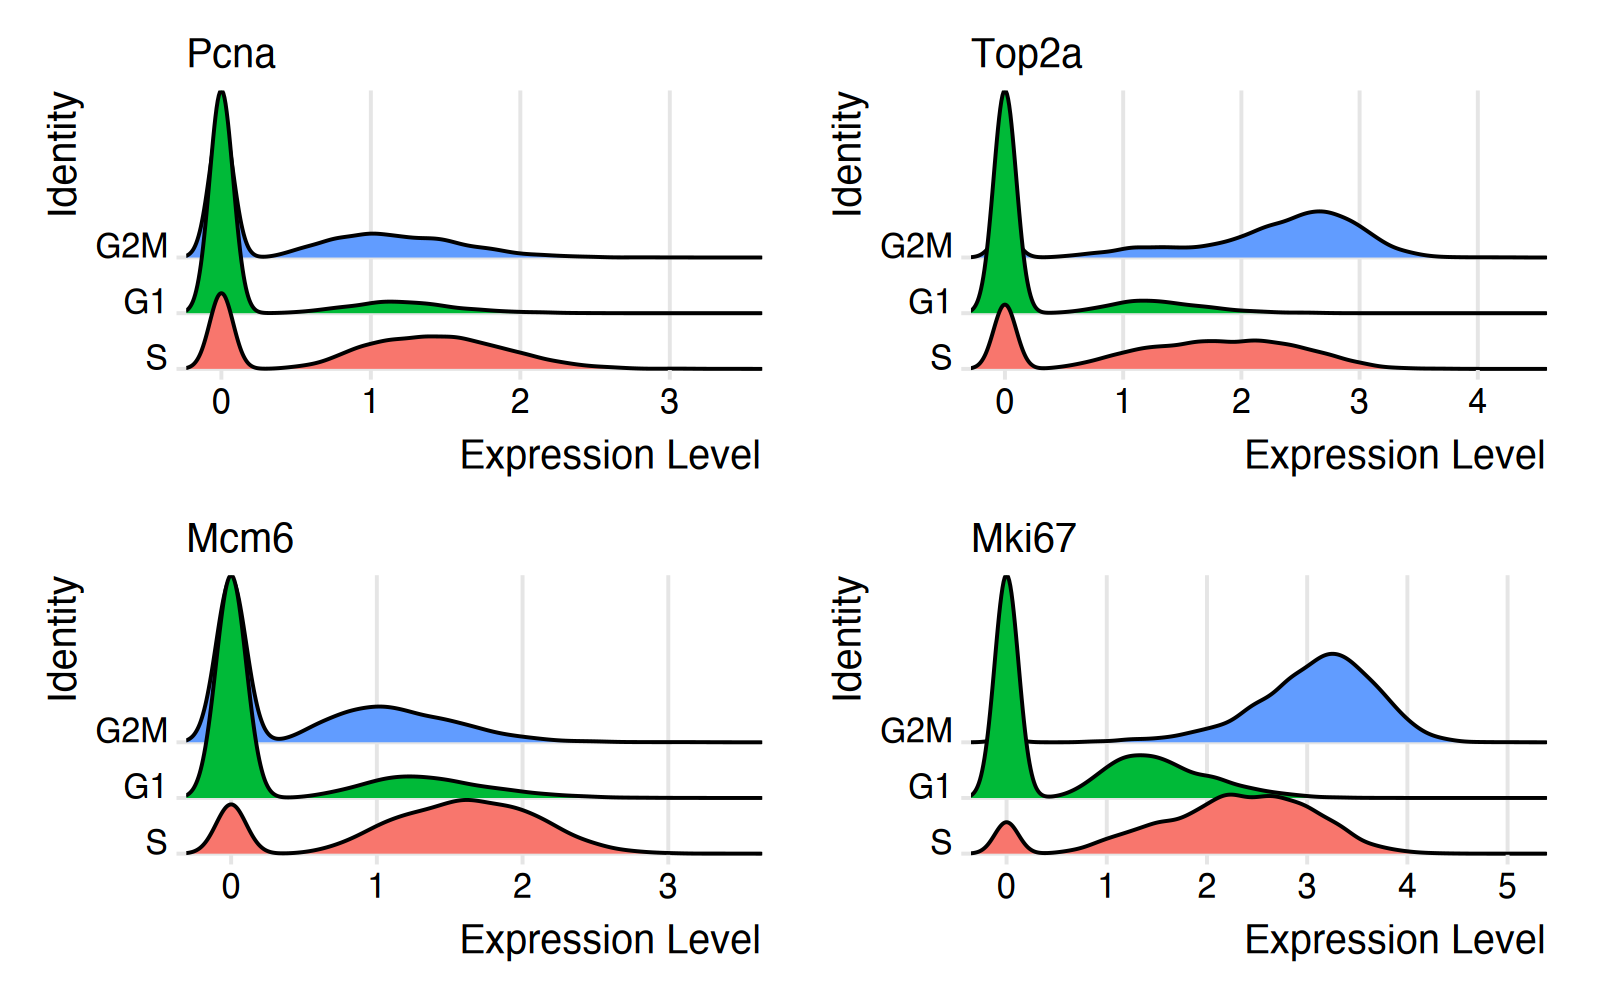

In [6]:
options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 200)
RidgePlot(sc_data, features = c("Pcna", "Top2a", "Mcm6", "Mki67"), ncol = 2)

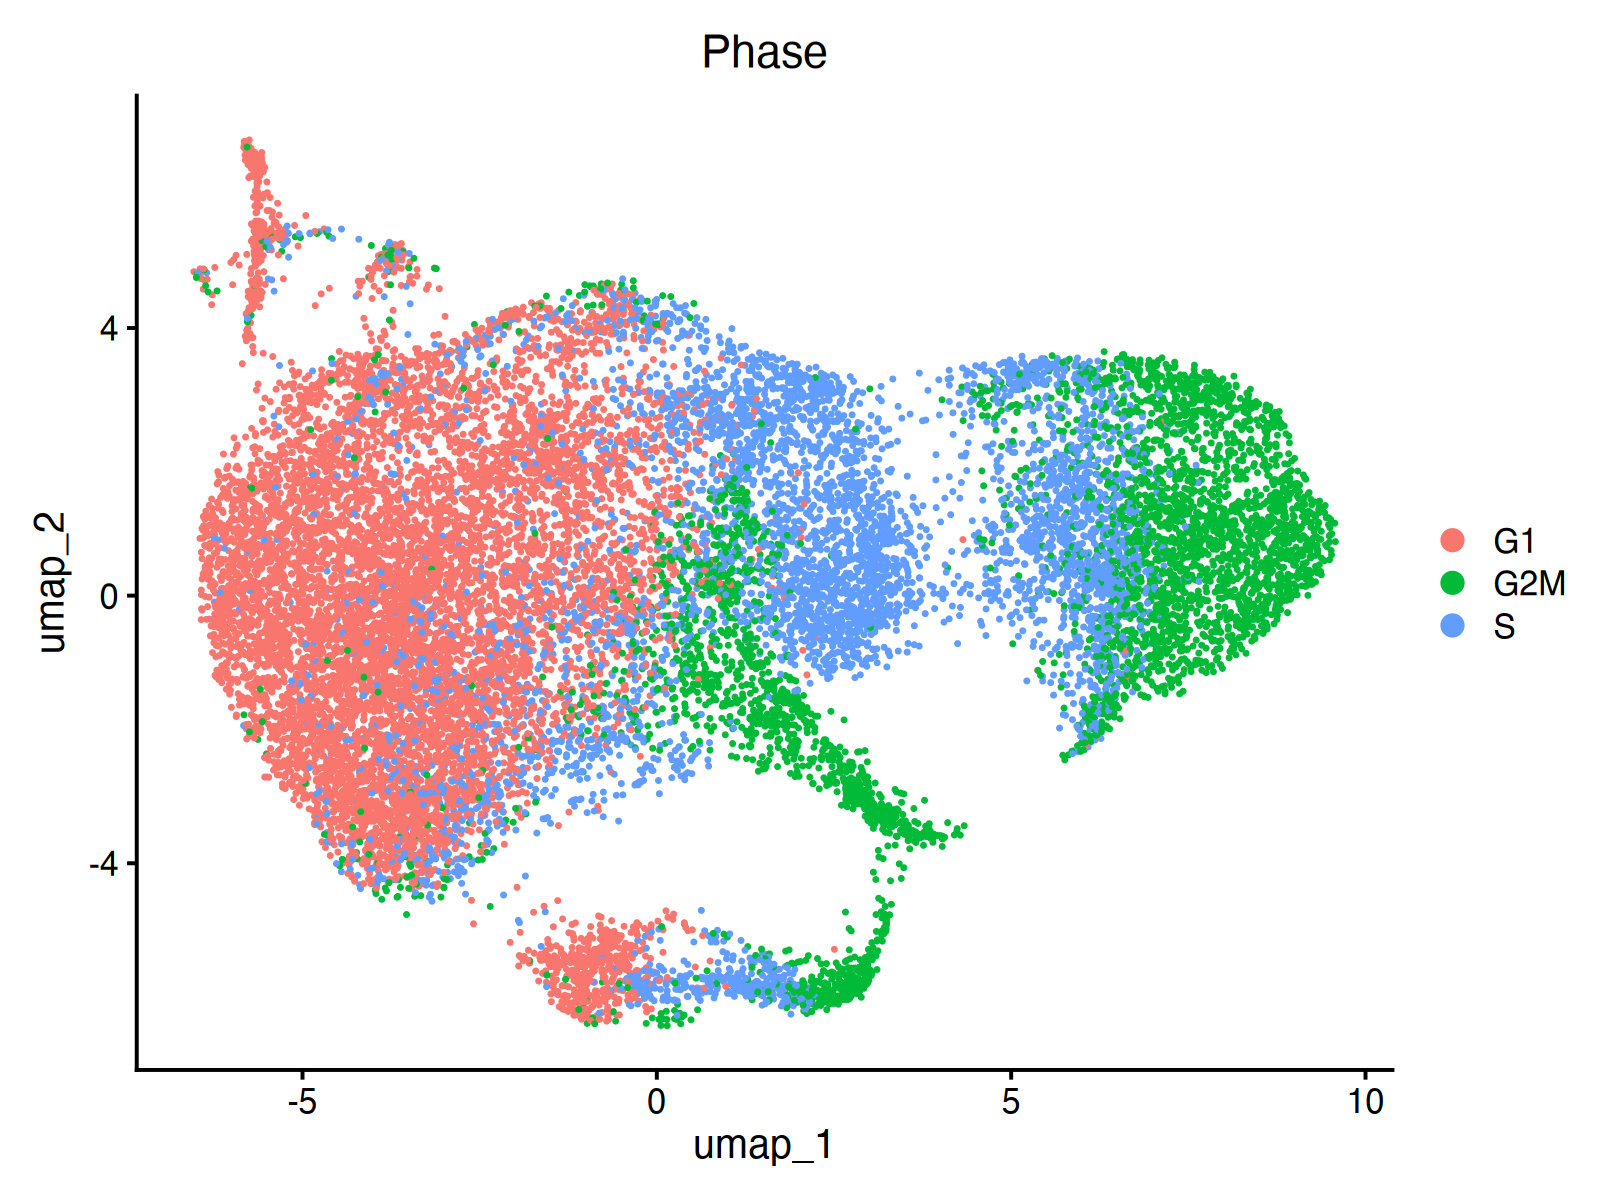

In [7]:
options(repr.plot.width = 8, repr.plot.height = 6, repr.plot.res = 200)
DimPlot(sc_data, reduction = "umap", group.by = "Phase")


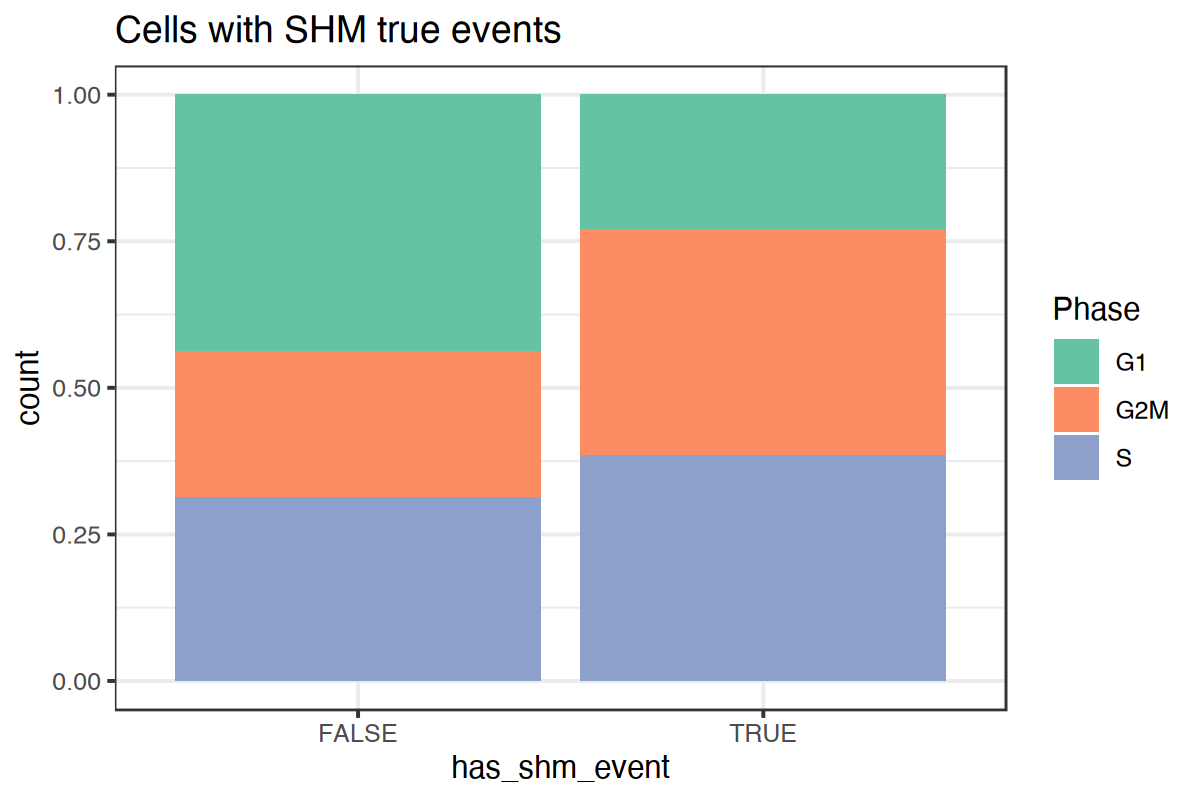

In [9]:
options(repr.plot.width = 6, repr.plot.height = 4, repr.plot.res = 200)
ggplot(sc_data@meta.data %>% filter(orig.ident != "KO"), aes(x = has_shm_event, fill = Phase)) +
  geom_bar(position = "fill") +
  theme_bw() +
  labs(title = "Cells with SHM true events") +
  scale_fill_brewer(palette = "Set2")

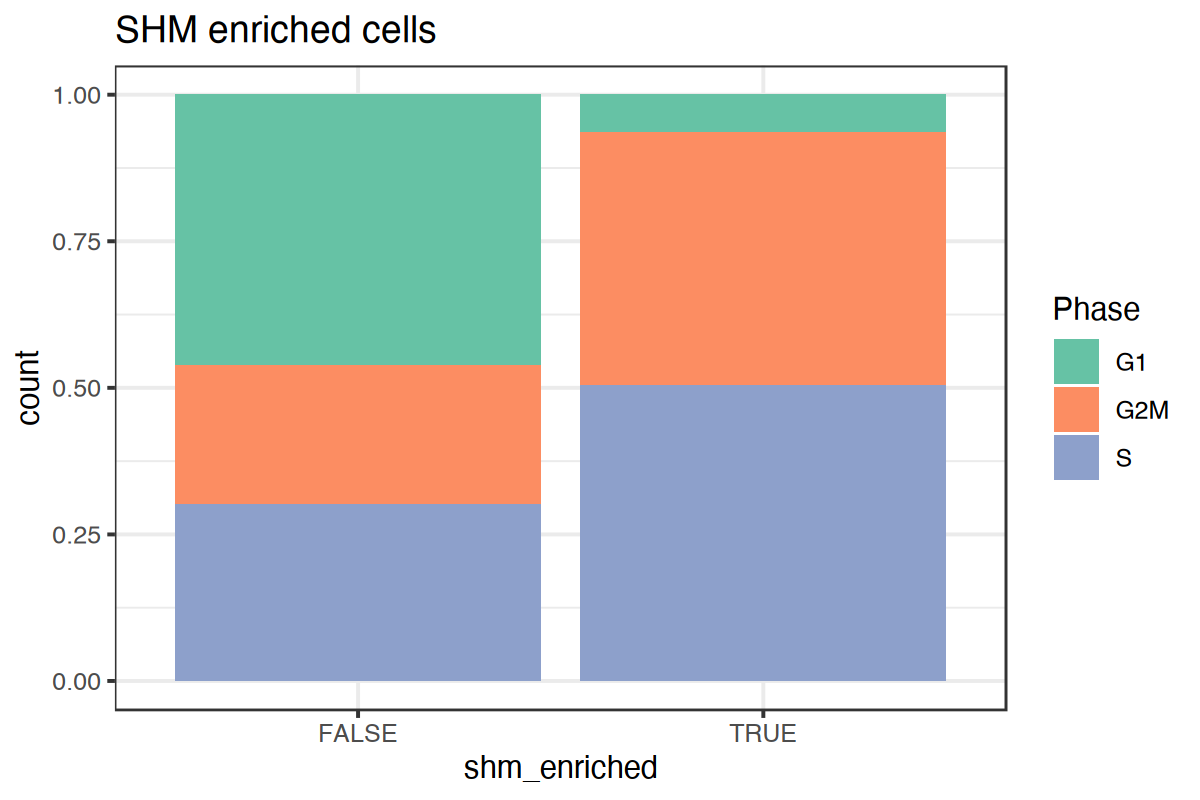

In [10]:
options(repr.plot.width = 6, repr.plot.height = 4, repr.plot.res = 200)
ggplot(sc_data@meta.data %>% filter(orig.ident != "KO"), aes(x = shm_enriched, fill = Phase)) +
  geom_bar(position = "fill") +
  theme_bw() +
  labs(title = "SHM enriched cells") +
  scale_fill_brewer(palette = "Set2")

## Tricycle


In [5]:
sc_data <- Runtricycle(
  sc_data,
  slot = "data",
  reduction.name = "tricycleEmbedding",
  reduction.key = "tricycleEmbedding_",
  gname.type = "SYMBOL",
  species = "human"
)

No custom reference projection matrix provided. The ref learned from mouse Neuroshpere data will be used.

The number of projection genes found in the new data is 165.



Warning message:
“The `slot` argument of `FetchData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


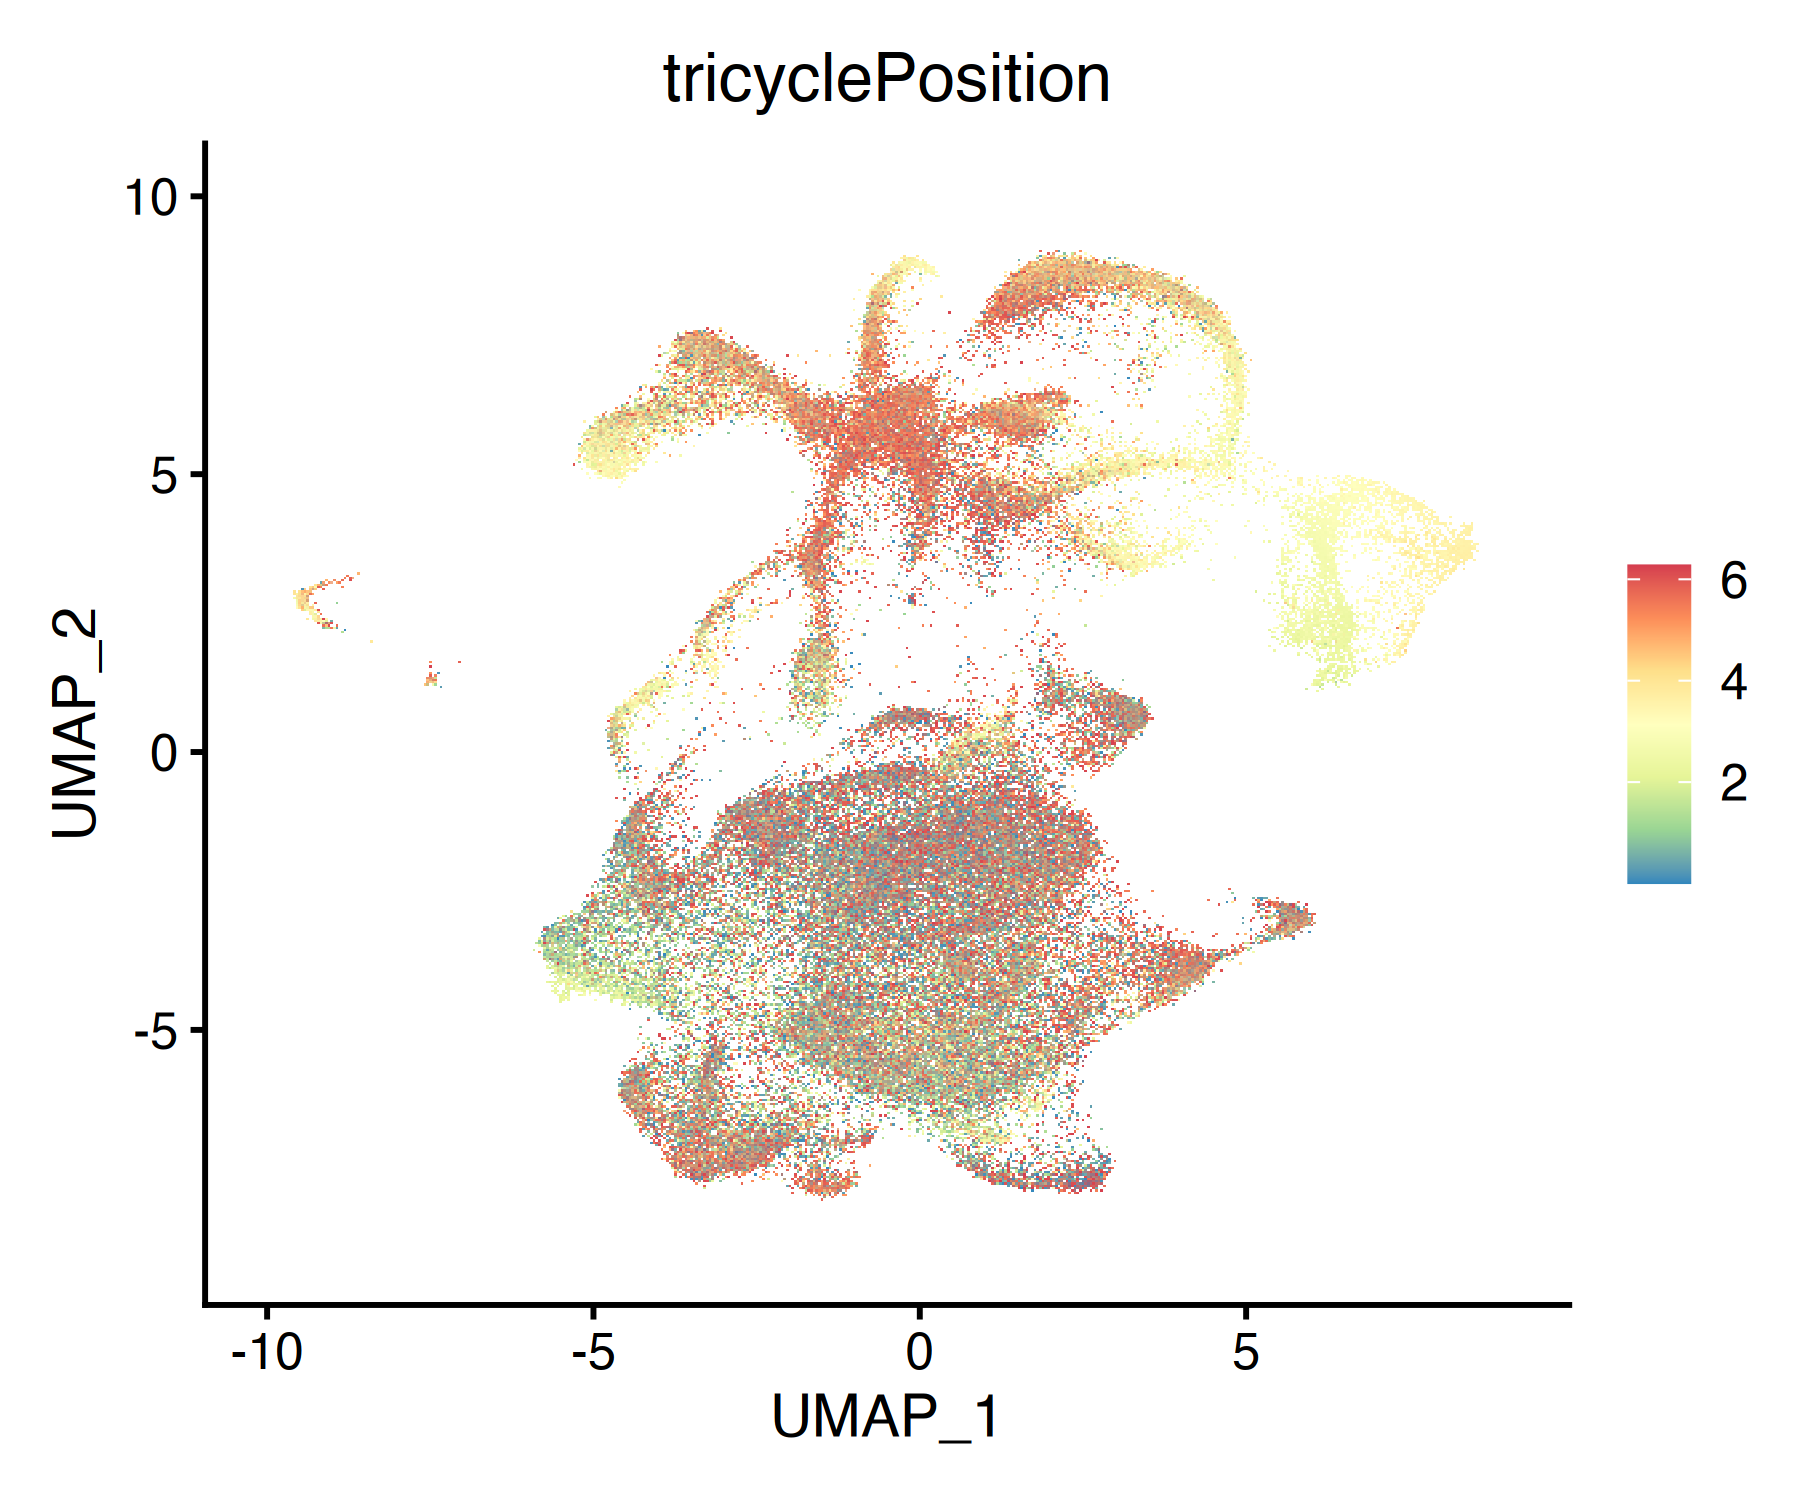

In [6]:
options(repr.plot.width = 6, repr.plot.height = 5, repr.plot.res = 300)
FeaturePlot(sc_data, "tricyclePosition", reduction = "umap") +
  scale_color_distiller(palette = "Spectral")

In [13]:
plot_df <- FetchData(
  object = sc_data,
  vars = c(
    "tricycleEmbedding_1",
    "tricycleEmbedding_2",
    "tricyclePosition",
    "orig.ident",
#    "has_shm_event",
#    "shm_enriched",
    "TOP2A"
  )
)
write.csv(
  plot_df %>% select(tricycleEmbedding_1, tricycleEmbedding_2, tricyclePosition),
  "output/tricycle_results.csv"
)
head(plot_df)

,tricycleEmbedding_1,tricycleEmbedding_2,tricyclePosition,orig.ident,TOP2A
,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
AAACCTGAGATCACGG-1_1,0.67238129,-0.31625357,5.8435390,K1B,0.02463917
AAACCTGAGCCAGTTT-1_1,0.10452545,-0.12046610,5.4270553,K1B,0.06263621
AAACCTGAGCGGCTTC-1_1,0.23824338,0.30083947,0.9009964,K1B,0.07584903
AAACCTGAGGCATGTG-1_1,0.26776980,-0.04888678,6.1026040,K1B,0.03095144
AAACCTGAGTGTTTGC-1_1,0.08722435,0.11287060,0.9128735,K1B,0.04434876
AAACCTGCAACTGCTA-1_1,0.29630019,0.16339069,0.5039453,K1B,0.05497480


In [21]:
sc_data[[]]

,orig.ident,nCount_RNA,nFeature_RNA,integrated_snn_res.0.3,seurat_clusters,scSHM,tricyclePosition
,<chr>,<dbl>,<int>,<fct>,<fct>,<lgl>,<dbl>
AAACCTGAGATCACGG-1_1,K1B,3273,1471,2,2,FALSE,5.84353896
AAACCTGAGCCAGTTT-1_1,K1B,5993,1886,4,4,FALSE,5.42705533
AAACCTGAGCGGCTTC-1_1,K1B,6318,2544,2,2,FALSE,0.90099639
AAACCTGAGGCATGTG-1_1,K1B,3102,1317,0,0,FALSE,6.10260399
AAACCTGAGTGTTTGC-1_1,K1B,2582,1179,4,4,FALSE,0.91287354
AAACCTGCAACTGCTA-1_1,K1B,2894,1236,0,0,FALSE,0.50394529
AAACCTGCACCACCAG-1_1,K1B,3710,1583,6,6,FALSE,0.04558045
AAACCTGCATGCCACG-1_1,K1B,3077,1177,0,0,FALSE,0.41753241
AAACCTGCATTTCAGG-1_1,K1B,3078,1347,2,2,FALSE,5.83467170


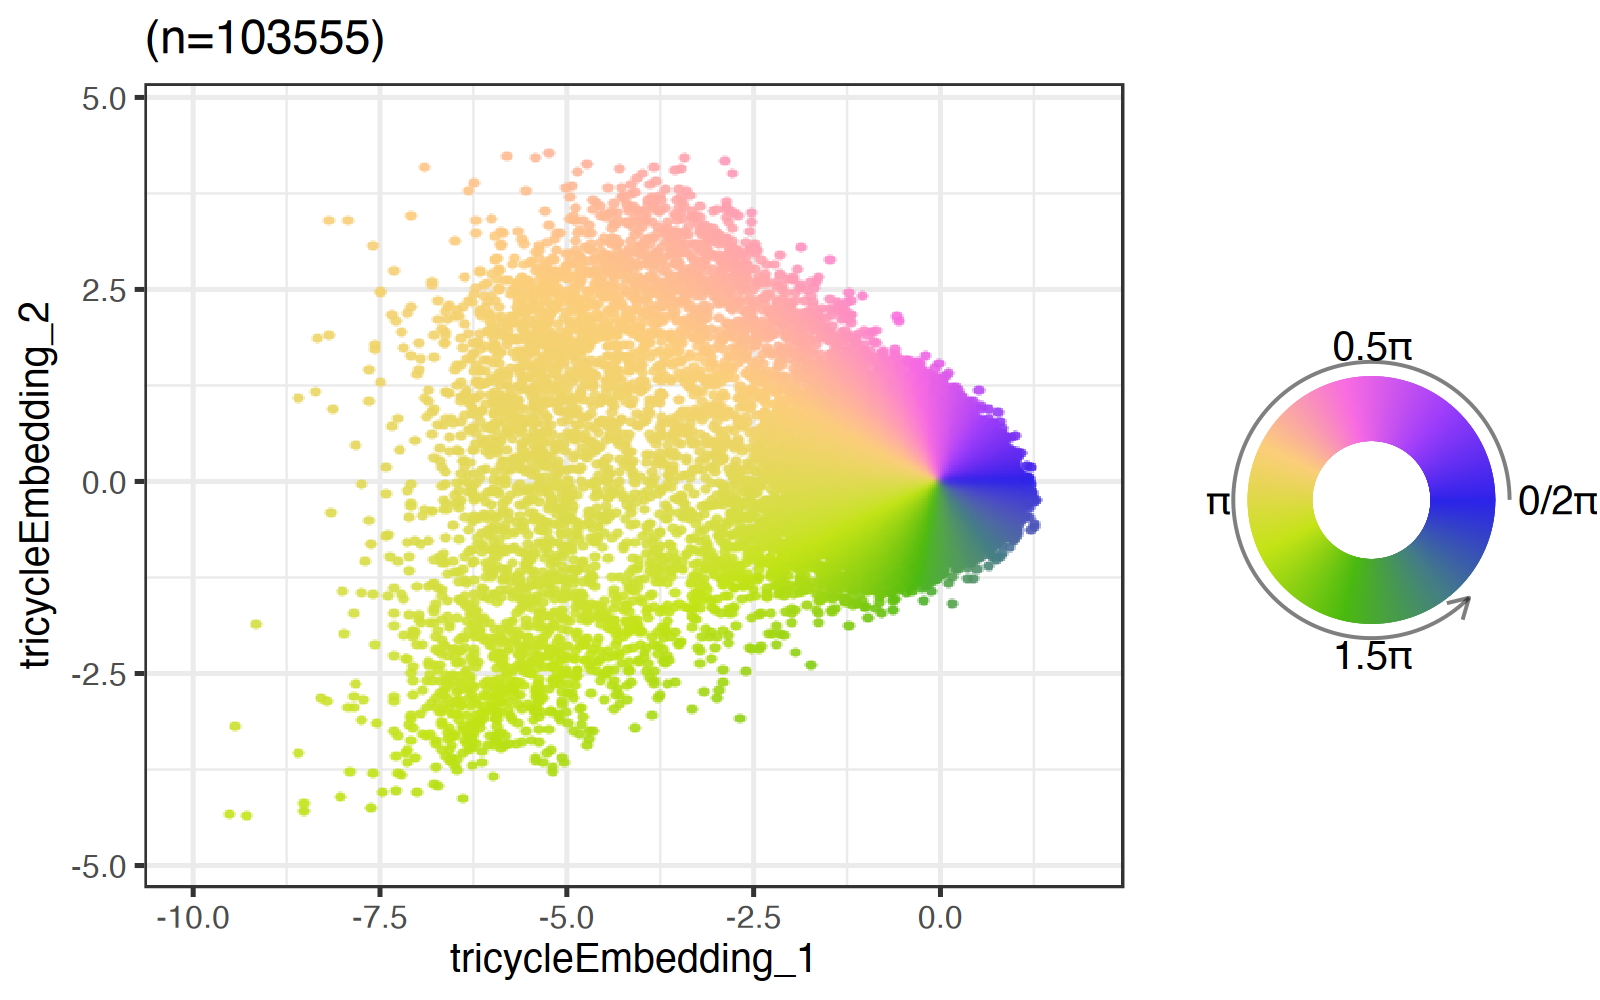

In [12]:
options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 200)
p <- tricycle:::.plot_emb_circle_scale(
  emb.m = plot_df[, 1:2],
  color.value = plot_df$tricyclePosition,
  color_by = "tricyclePosition", point.size = 3.5, point.alpha = 0.9
) + theme_bw(base_size = 14)
legend <- circle_scale_legend(text.size = 5, alpha = 0.9)
plot_grid(p, legend, ncol = 2, rel_widths = c(1, 0.4))

In [16]:
fit.l <- fit_periodic_loess(
  sc_data$tricyclePosition,
  plot_df$TOP2A,
  plot = TRUE,
  x_lab = "Cell cycle position θ",
  y_lab = "log2(Top2a)",
  fig.title = paste0("Expression of Top2a along θ (n=", ncol(sc_data), ")")
)
names(fit.l)

Warning message in data.frame(theta = theta.v, y = y):
“row names were found from a short variable and have been discarded”


[1] "fitted"   "residual" "pred.df"  "loess.o"  "rsquared" "fig"

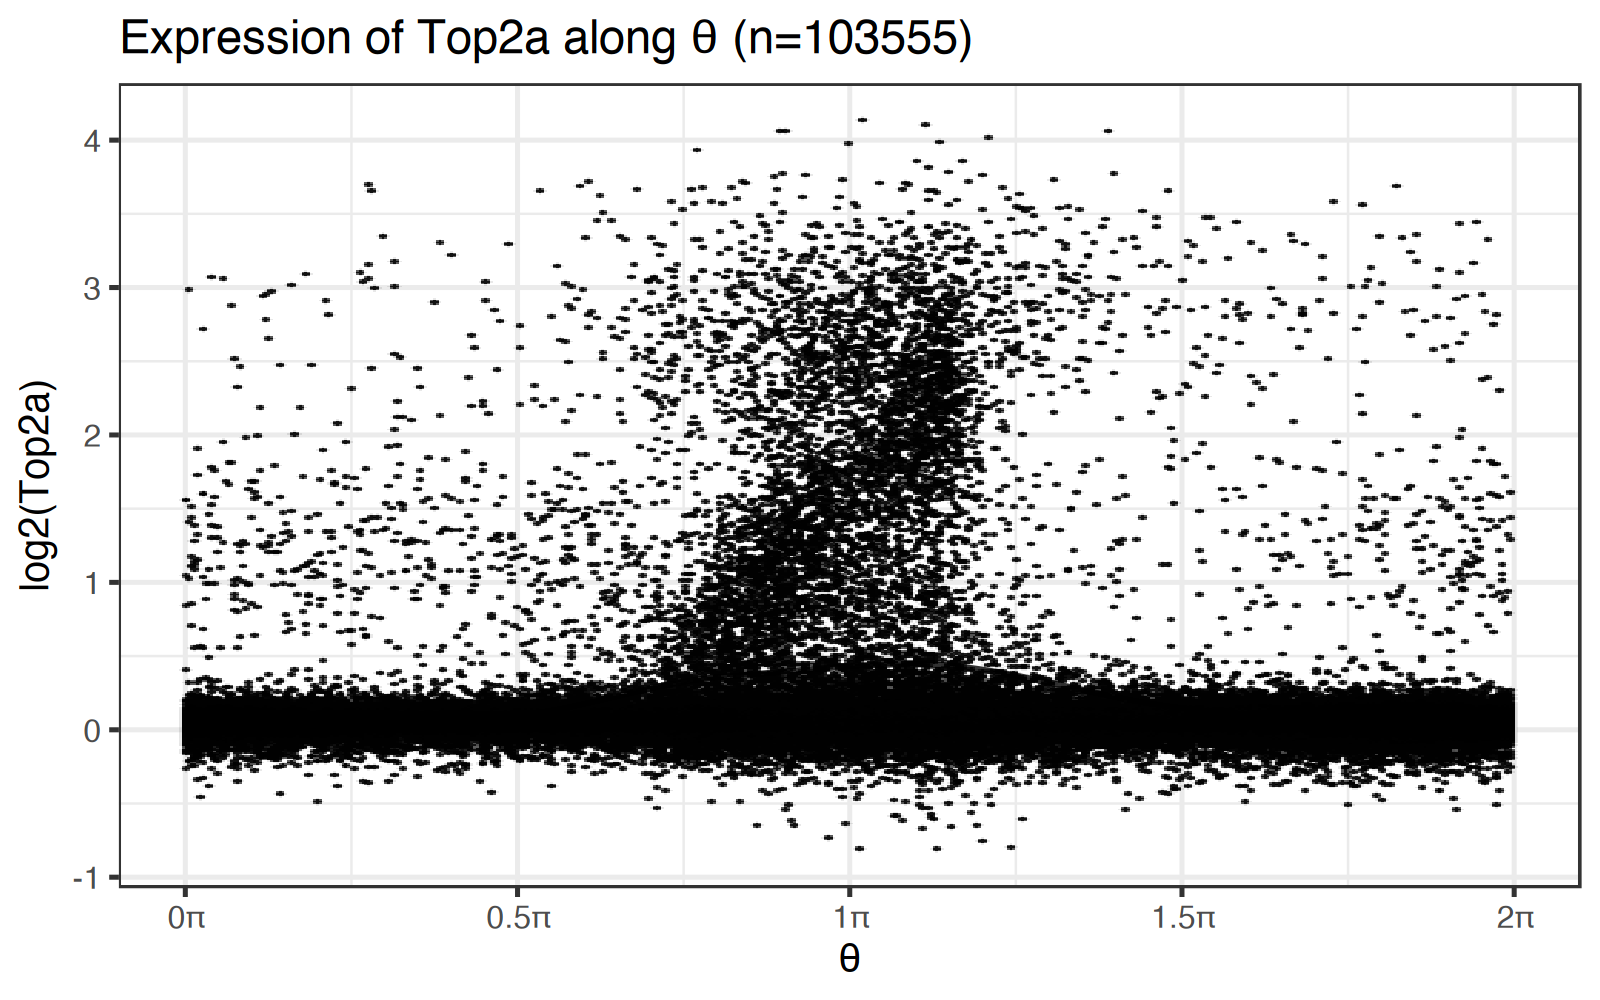

In [17]:
fit.l$fig + theme_bw(base_size = 14)


In [18]:
plot_df_noko <- plot_df %>% filter(orig.ident != "KO")

In [20]:
options(repr.plot.width = 9, repr.plot.height = 5, repr.plot.res = 200)
tricycle::plot_ccposition_den(
  plot_df$tricyclePosition,
  plot_df$orig.ident,
  bw = 10
) + theme_bw(base_size = 14)

Warning message in tricycle::plot_ccposition_den(plot_df$tricyclePosition, plot_df$orig.ident, :
“The number of levels of color_var.v is greater than 8.
 Only the top 8 levels of most cell will be shown.
You can show them all by feeding enough colors in palette.v.”
Warning message in brewer.pal(nlevels(color_var.v), "Set1"):
“n too large, allowed maximum for palette Set1 is 9
Returning the palette you asked for with that many colors
”
NA found in color_var.v. 
The cells with NA will be considered for global density but not stratified densities.



ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'args' in selecting a method for function 'do.call': dim(X) must have a positive length


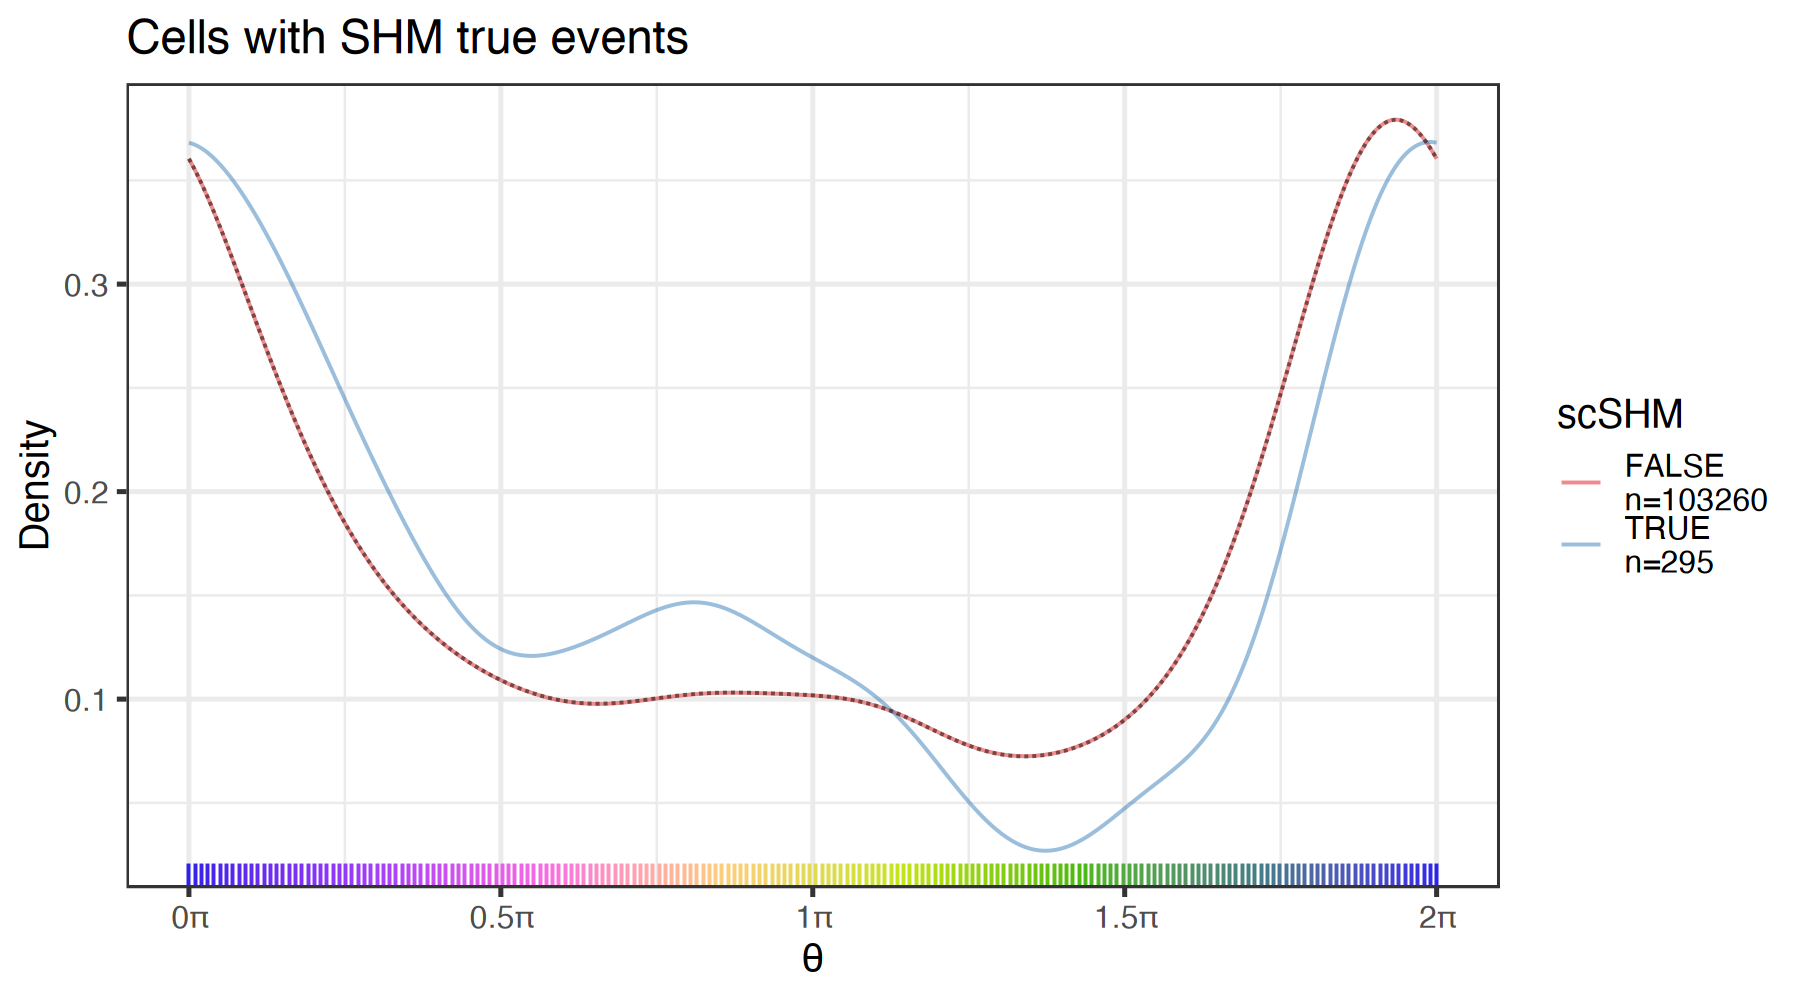

In [22]:
tricycle::plot_ccposition_den(
  sc_data[[]]$tricyclePosition,
  sc_data[[]]$scSHM,
  "scSHM",
  bw = 10
) +
  theme_bw(base_size = 14) +
  labs(title = "Cells with SHM true events")

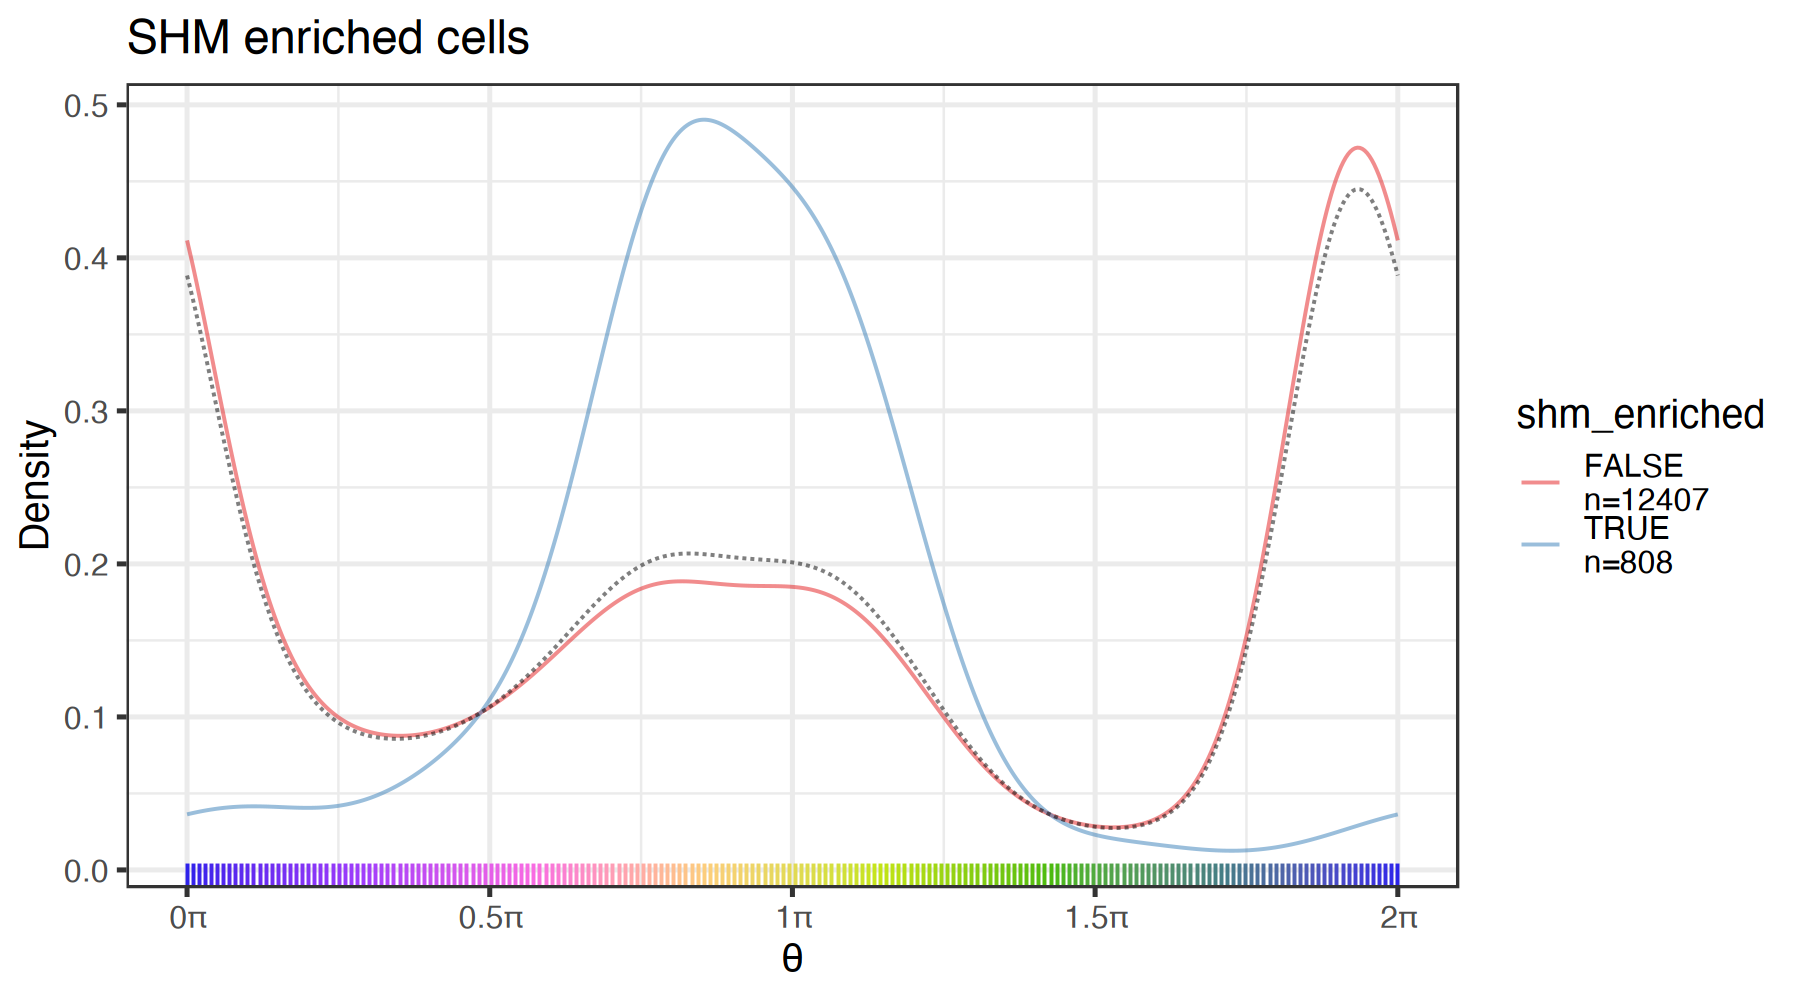

In [20]:
tricycle::plot_ccposition_den(
  plot_df_noko$tricyclePosition,
  plot_df_noko$shm_enriched,
  "shm_enriched",
  bw = 10
) +
  theme_bw(base_size = 14) +
  labs(title = "SHM enriched cells")